# Edge Detection Operators

This notebook demonstrates edge detection using various kernels to locate **object boundaries** in the BMW image.

Three edge detection techniques are implemented:
1. **Sobel** — uses Sobel kernels to compute gradient magnitude and detect edges.
2. **Prewitt** — uses Prewitt kernels to compute gradient magnitude and detect edges.
3. **Canny** — a multi-stage edge detector (Gaussian blur → gradient → non-maximum suppression → hysteresis thresholding).

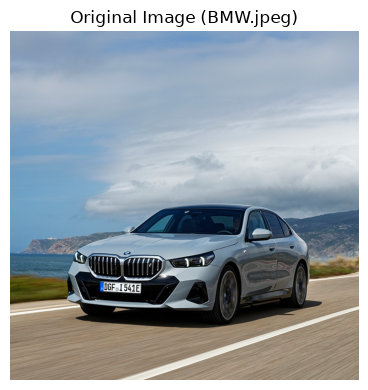

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load the image

Read `BMW.jpeg` and convert to grayscale for edge detection.

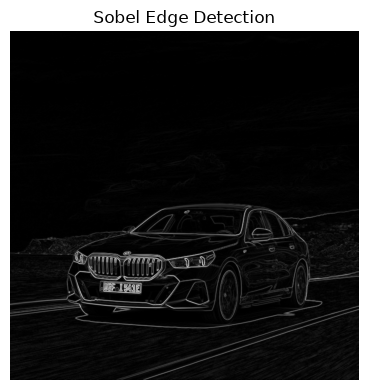

In [2]:
image_path = 'BMW.jpeg'

gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if gray is None:
    raise FileNotFoundError(f'Could not load image: {image_path}')

rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(rgb)
plt.title('Original Image (BMW.jpeg)')
plt.axis('off')
plt.show()

## 1. Sobel Edge Detection

The Sobel operator uses two 3×3 kernels — one for horizontal gradients (Gx) and one for vertical gradients (Gy).
The edge magnitude is computed as `sqrt(Gx² + Gy²)`.

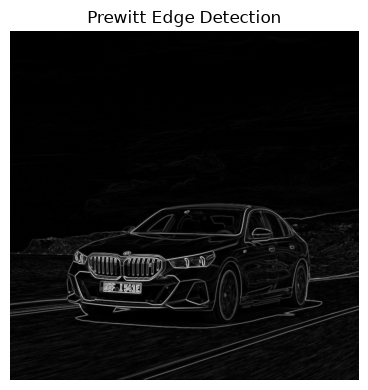

In [3]:
def sobel_edge_detection(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(magnitude)

sobel_edges = sobel_edge_detection(gray)

plt.figure(figsize=(6, 4))
plt.imshow(sobel_edges, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.show()

## 2. Prewitt Edge Detection

The Prewitt operator uses two 3×3 kernels — one for horizontal gradients (Gx) and one for vertical gradients (Gy).
Like Sobel, the edge magnitude is `sqrt(Gx² + Gy²)`.

Kernels:
- Gx = [[-1,-1,-1],[0,0,0],[1,1,1]]
- Gy = [[-1,0,1],[-1,0,1],[-1,0,1]]

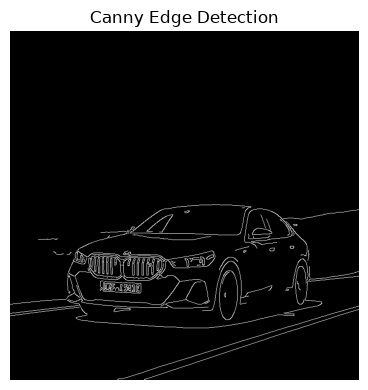

In [4]:
def prewitt_edge_detection(image):
    kernel_x = np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]])
    kernel_y = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]])
    gx = cv2.filter2D(image, cv2.CV_64F, kernel_x)
    gy = cv2.filter2D(image, cv2.CV_64F, kernel_y)
    magnitude = np.sqrt(gx**2 + gy**2)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(magnitude)

prewitt_edges = prewitt_edge_detection(gray)

plt.figure(figsize=(6, 4))
plt.imshow(prewitt_edges, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

## 3. Canny Edge Detection

The Canny edge detector is a multi-stage algorithm:
1. Gaussian blur to reduce noise
2. Sobel gradient computation (Gx, Gy)
3. Gradient magnitude and direction
4. Non-maximum suppression to thin edges
5. Double thresholding to classify strong/weak edges
6. Hysteresis to link strong and weak edges

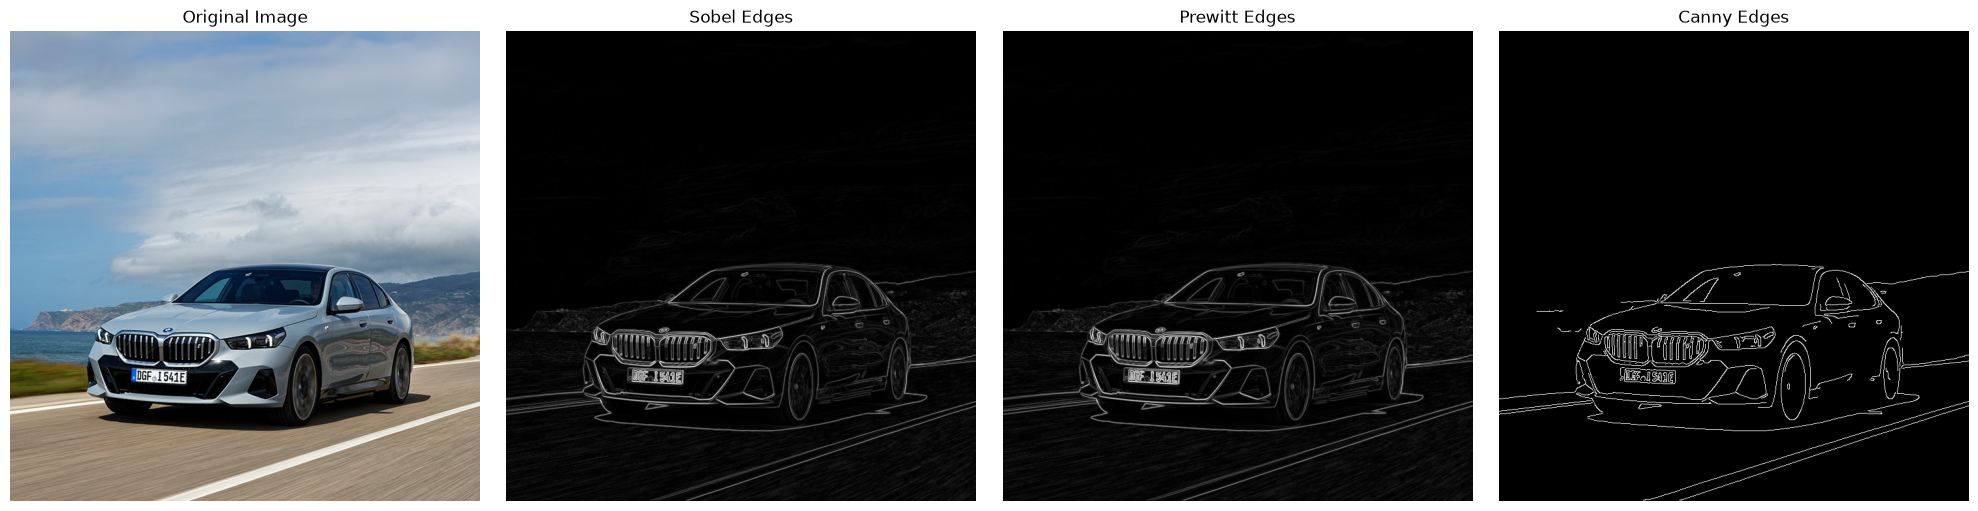

In [5]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

canny_edges = cv2.Canny(blurred, 100, 200)

plt.figure(figsize=(6, 4))
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

## Comparison of all edge detection operators

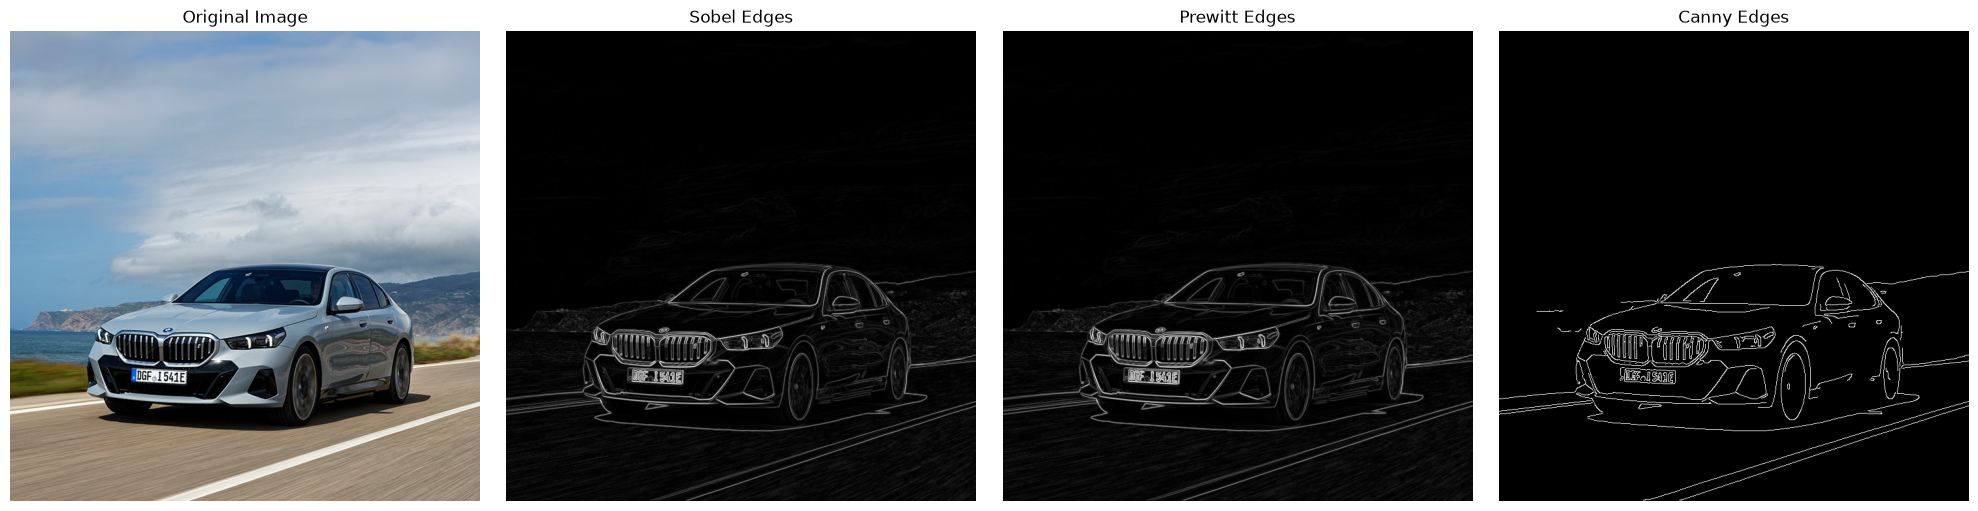

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sobel_edges, cmap='gray')
axes[1].set_title('Sobel Edges')
axes[1].axis('off')

axes[2].imshow(prewitt_edges, cmap='gray')
axes[2].set_title('Prewitt Edges')
axes[2].axis('off')

axes[3].imshow(canny_edges, cmap='gray')
axes[3].set_title('Canny Edges')
axes[3].axis('off')

plt.tight_layout()
plt.show()